# LLR Comparison: Base ESM2 vs Per-Pfam LoRA-Finetuned

Loads the per-pfam LLR comparison payloads produced by
`ESM_domainome_llr_pfam_compare_dictall.ipynb` (one
`llr_comparison_all.pkl.gz` per pfam under
`gs://{bucket}/ESM2/ft_per_pfam/global_finetune/{pfam_id}/`), then for every
(pfam model × domain) pair computes Spearman ρ of measured fitness vs base
and finetuned LLR. Results are aggregated into a single `corr_df` with a
`model` column identifying which pfam-finetuned LoRA produced each row.


In [1]:
import os
import io
import gzip
import json
import pickle
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from tqdm import tqdm
from dotenv import load_dotenv
from transformers import EsmForMaskedLM, EsmTokenizer
from peft import LoraConfig, get_peft_model
from google.cloud import storage

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Constants (must match training run) ──────────────────────────────────────

AA_ORDER         = ['L', 'A', 'G', 'V', 'S', 'E', 'R', 'T', 'I', 'D',
                    'P', 'K', 'Q', 'N', 'F', 'Y', 'M', 'H', 'W', 'C']
FITNESS_AA_ORDER = list("ACDEFGHIKLMNPQRSTVWY")
MODEL_NAME       = "facebook/esm2_t33_650M_UR50D"
MAX_LEN          = 1022
LORA_DROPOUT     = 0.1

# ── Local + GCS layout (must match per-pfam compare run) ─────────────────────

OUTPUT_DIR    = "finetuned_models_v2"
RUN_ID_PREFIX = "global_finetune"   # matches per-pfam compare notebook
os.makedirs(OUTPUT_DIR, exist_ok=True)

GCS_PROJECT           = "plm-study-484223"
GCS_BUCKET            = "domainome-data"
GCS_DOMAIN_DATA_BLOB  = "ESM2/dict_fitness.pkl.gz"
GCS_FULL_PROTEIN_BLOB = "ESM2/dict_domainome_uniprot_new.pkl.gz"
GCS_OUTPUT_PREFIX     = "ESM2/ft_per_pfam/"   # must end with /

LLR_OUTPUT_NAME = "llr_comparison_all.pkl.gz"


def pfam_paths(pfam_id):
    """Resolve per-pfam local + GCS paths for the per-pfam compare payload."""
    run_id  = f"{RUN_ID_PREFIX}/{pfam_id}"
    run_dir = os.path.join(OUTPUT_DIR, run_id)
    return {
        "run_id":    run_id,
        "run_dir":   run_dir,
        "llr_local": os.path.join(run_dir, LLR_OUTPUT_NAME),
        "gcs_llr":   f"{GCS_OUTPUT_PREFIX}{run_id}/{LLR_OUTPUT_NAME}",
    }


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
# ── GCS Helpers ──────────────────────────────────────────────────────────────
load_dotenv()
cred_path = os.getenv('GOOGLE_APPLICATION_CREDENTIALS')

os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = cred_path

# _gcs_client = storage.Client(project=GCS_PROJECT) if GCS_PROJECT else storage.Client()
_gcs_client = storage.Client()
_gcs_bucket = _gcs_client.bucket(GCS_BUCKET)


def gcs_download_pickle_gz(blob):
    data = blob.download_as_bytes()
    with gzip.GzipFile(fileobj=io.BytesIO(data), mode="rb") as gz:
        return pickle.load(gz)


def gcs_download_to_file(blob_path, local_path):
    blob = _gcs_bucket.blob(blob_path)
    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    blob.download_to_filename(local_path)
    return local_path


def gcs_upload_file(blob_path, local_path, content_type="application/octet-stream"):
    blob = _gcs_bucket.blob(blob_path)
    blob.upload_from_filename(local_path, content_type=content_type)

In [4]:
# ── Helpers (mirrored from training notebook) ────────────────────────────────

def truncate_to_domain(sequence, domain_start, domain_end, max_len=MAX_LEN):
    seq_len    = len(sequence)
    domain_mid = (domain_start + domain_end) // 2
    half       = max_len // 2
    start      = max(0, domain_mid - 1 - half)
    end        = start + max_len
    if end > seq_len:
        end   = seq_len
        start = max(0, end - max_len)
    return sequence[start:end], start


def get_LLR_scores(sequence, model, tokenizer, device):
    seq_list  = list(sequence)
    tokenized = tokenizer(sequence, padding=False, truncation=True,
                          max_length=1024, return_tensors="pt")
    input_ids = tokenized["input_ids"].to(device)

    logits    = model(input_ids).logits
    log_probs = torch.log_softmax(logits, dim=-1)
    wt_logits = log_probs[:, 1:-1, :].squeeze(0)

    wt_logits_df = pd.DataFrame(
        wt_logits[:, 4:24].cpu().detach().numpy(),
        columns=AA_ORDER,
        index=[f"{aa} {i+1}" for i, aa in enumerate(seq_list)]
    ).T

    wt_norm = np.diag(wt_logits_df.loc[[c.split(" ")[0] for c in wt_logits_df.columns]])
    LLR     = wt_logits_df - wt_norm
    return LLR, wt_logits, seq_list


def fitness_matrix_to_rows(fitness, dom_seq, position_offset=0):
    rows = []
    for i, wt_aa in enumerate(dom_seq):
        if i >= len(fitness):
            break
        row = fitness[i]
        for j, mut_aa in enumerate(FITNESS_AA_ORDER):
            if j >= len(row):
                continue
            val = row[j]
            if val is None:
                continue
            try:
                fval = float(val)
            except (TypeError, ValueError):
                continue
            if np.isnan(fval):
                continue
            if mut_aa == wt_aa:
                continue
            rows.append({
                "position":           position_offset + i + 1,
                "wt_aa":              wt_aa,
                "mut_aa":             mut_aa,
                "normalized_fitness": fval,
            })
    return rows


def build_lora_model(lora_r, lora_alpha):
    """Rebuild the exact ESM2 + LoRA architecture used during training."""
    model       = EsmForMaskedLM.from_pretrained(MODEL_NAME)
    lora_config = LoraConfig(
        task_type      = "FEATURE_EXTRACTION",
        r              = lora_r,
        lora_alpha     = lora_alpha,
        target_modules = ["query", "key", "value", "output.dense"],
        lora_dropout   = LORA_DROPOUT,
    )
    model = get_peft_model(model, lora_config)
    return model

In [5]:
# ── Discover pfams + load all per-pfam payloads (skip recompute) ─────────────
#
# Lists every `llr_comparison_all.pkl.gz` under
# gs://{GCS_BUCKET}/{GCS_OUTPUT_PREFIX}{RUN_ID_PREFIX}/{pfam_id}/, downloads
# any that aren't cached locally, and loads them into
# `pfam_payloads[pfam_id]`. Each payload's `domains` dict has the same shape
# as the single-model run: {domain_id: {sequence, base_llr, ft_llr, ...}}.

_run_prefix = f"{GCS_OUTPUT_PREFIX}{RUN_ID_PREFIX}/"

PFAM_IDS = sorted({
    blob.name[len(_run_prefix):].split("/", 1)[0]
    for blob in _gcs_client.list_blobs(GCS_BUCKET, prefix=_run_prefix)
    if blob.name.endswith(f"/{LLR_OUTPUT_NAME}")
})

print(f"Found {len(PFAM_IDS)} pfams under gs://{GCS_BUCKET}/{_run_prefix}")
print(PFAM_IDS[:10], "..." if len(PFAM_IDS) > 10 else "")

pfam_payloads = {}

for pfam_id in tqdm(PFAM_IDS, desc="Load pfam payloads"):
    paths = pfam_paths(pfam_id)
    if not os.path.exists(paths["llr_local"]):
        try:
            gcs_download_to_file(paths["gcs_llr"], paths["llr_local"])
        except Exception as exc:
            tqdm.write(f"[{pfam_id}] download failed: {exc}")
            continue
    with gzip.open(paths["llr_local"], "rb") as gz:
        pfam_payloads[pfam_id] = pickle.load(gz)

print(f"Loaded payloads for {len(pfam_payloads)} pfams")
if pfam_payloads:
    sample_pfam    = next(iter(pfam_payloads))
    sample_payload = pfam_payloads[sample_pfam]
    sample_id      = next(iter(sample_payload["domains"]))
    sample         = sample_payload["domains"][sample_id]
    print(f"Sample pfam={sample_pfam} domain={sample_id} "
          f"seq_len={len(sample['sequence'])} "
          f"base_llr={sample['base_llr'].shape} "
          f"ft_llr={sample['ft_llr'].shape}")

Using local LLR comparison: finetuned_models_v2/global_finetune/llr_comparison.pkl.gz
Loaded payload for run_id=global_finetune model=facebook/esm2_t33_650M_UR50D
Domains in payload: 522
Sample domain: A0A2R8Y422_PF00240_2  seq_len=70  base_llr=(20, 70)  ft_llr=(20, 70)


In [6]:
# ── Spearman: fitness vs (base LLR, finetuned LLR) per (model × domain) ─────
#
# For every pfam-finetuned model in `pfam_payloads` and every domain it
# scored, line up each measured (position, mut_aa) fitness value with the
# corresponding entry in that model's base and finetuned LLR matrices and
# compute Spearman ρ separately for base and ft. The resulting `corr_df`
# carries a `model` column equal to the pfam id of the LoRA-finetuned model
# whose ft_llr produced that row.

from scipy.stats import spearmanr

try:
    fitness_dict
except NameError:
    print(f"Loading fitness dict from gs://{GCS_BUCKET}/{GCS_DOMAIN_DATA_BLOB}")
    fitness_dict = gcs_download_pickle_gz(_gcs_bucket.blob(GCS_DOMAIN_DATA_BLOB))
    print(f"Loaded {len(fitness_dict)} fitness entries")

aa_to_row = {aa: i for i, aa in enumerate(AA_ORDER)}

per_domain_rows = []
skipped_no_match = 0
skipped_too_few  = 0

for pfam_model_id, payload in tqdm(pfam_payloads.items(), desc="Pfam models"):
    for domain_id, entry in payload["domains"].items():
        fd = fitness_dict.get(domain_id)
        if not isinstance(fd, dict):
            continue
        fitness = fd.get("fitness")
        dom_seq = fd.get("dom_seq")
        if fitness is None or dom_seq is None:
            continue

        sequence = entry["sequence"]
        base_llr = entry["base_llr"]
        ft_llr   = entry["ft_llr"]
        n_pos    = base_llr.shape[1]

        idx_in_seq = sequence.find(dom_seq)
        if idx_in_seq < 0:
            skipped_no_match += 1
            continue

        fits, base_vals, ft_vals = [], [], []
        for i, wt_aa in enumerate(dom_seq):
            col = idx_in_seq + i
            if col >= n_pos or i >= len(fitness):
                break
            row = fitness[i]
            for j, mut_aa in enumerate(FITNESS_AA_ORDER):
                if j >= len(row):
                    continue
                val = row[j]
                if val is None or mut_aa == wt_aa:
                    continue
                try:
                    fval = float(val)
                except (TypeError, ValueError):
                    continue
                if np.isnan(fval):
                    continue
                r = aa_to_row.get(mut_aa)
                if r is None:
                    continue
                fits.append(fval)
                base_vals.append(float(base_llr[r, col]))
                ft_vals.append(float(ft_llr[r, col]))

        if len(fits) < 10:
            skipped_too_few += 1
            continue

        fits      = np.asarray(fits)
        base_vals = np.asarray(base_vals)
        ft_vals   = np.asarray(ft_vals)

        rho_base, p_base = spearmanr(fits, base_vals)
        rho_ft,   p_ft   = spearmanr(fits, ft_vals)

        per_domain_rows.append({
            "model":          pfam_model_id,
            "domain_id":      domain_id,
            "uniprot_id":     entry.get("uniprot_id"),
            "in_pfam_train":  bool(entry.get("in_pfam_train", False)),
            "n":              int(len(fits)),
            "rho_base":       float(rho_base),
            "p_base":         float(p_base),
            "rho_ft":         float(rho_ft),
            "p_ft":           float(p_ft),
            "delta_rho":      float(rho_ft - rho_base),
        })

corr_df = pd.DataFrame(per_domain_rows).sort_values("delta_rho", ascending=False)

print(f"Computed Spearman for {len(corr_df)} (model, domain) pairs "
      f"across {corr_df['model'].nunique() if len(corr_df) else 0} pfam models "
      f"(skipped {skipped_no_match} no-match, {skipped_too_few} too-few)")
print(f"Mean ρ_base : {corr_df['rho_base'].mean():+.4f}   "
      f"median {corr_df['rho_base'].median():+.4f}")
print(f"Mean ρ_ft   : {corr_df['rho_ft'].mean():+.4f}   "
      f"median {corr_df['rho_ft'].median():+.4f}")
print(f"Mean Δρ     : {corr_df['delta_rho'].mean():+.4f}   "
      f"median {corr_df['delta_rho'].median():+.4f}")
print(f"(model, domain) pairs improved (Δρ > 0): "
      f"{(corr_df['delta_rho'] > 0).sum()} / {len(corr_df)} "
      f"({(corr_df['delta_rho'] > 0).mean()*100:.1f}%)")

corr_df.head(10)

Loading fitness dict from gs://domainome-data/ESM2/dict_fitness.pkl.gz
Loaded 522 fitness entries


Spearman per domain: 100%|██████████| 522/522 [00:00<00:00, 578.32it/s]

Computed Spearman for 522 domains (skipped 0 no-match, 0 too-few)
Mean ρ_base : +0.4495   median +0.4486
Mean ρ_ft   : +0.4897   median +0.5075
Mean Δρ     : +0.0403   median +0.0312
Domains improved (Δρ > 0): 366 / 522 (70.1%)


,domain_id,uniprot_id,n,rho_base,p_base,rho_ft,p_ft,delta_rho
520,Q9Y6N9_PF00595_207,Q9Y6N9,1255,0.378841,4.165029e-44,0.626107,1.467751e-137,0.247267
153,P20936_PF00018_281,P20936,1158,0.422455,2.486852e-51,0.666935,6.863400e-150,0.244480
350,Q86VP1_PF18112_729,Q86VP1,494,0.299746,1.029321e-11,0.531722,2.118242e-37,0.231976
155,P22681_PF00627_854,P22681,850,0.235321,3.693812e-12,0.457595,3.239896e-45,0.222274
472,Q9P0J7_PF05605_76,Q9P0J7,1093,0.303563,9.848891e-25,0.520061,9.077835e-77,0.216498
452,Q9HA38_PF12171_246,Q9HA38,493,0.241383,5.750199e-08,0.454480,1.686851e-26,0.213098
304,Q15911_PF00046_2147,Q15911,1055,0.320946,1.057353e-26,0.530762,1.016154e-77,0.209816
212,P55265_PF02295_296,P55265,1147,0.248485,1.334603e-17,0.452707,4.930962e-59,0.204222
352,Q86XK2_PF02207_849,Q86XK2,867,0.280419,3.949598e-17,0.481052,2.051741e-51,0.200633
488,Q9UJ78_PF06467_334,Q9UJ78,678,0.186344,1.029017e-06,0.376808,2.681287e-24,0.190464


In [7]:
corr_df['pfam'] = corr_df['domain_id'].str.split("_").str[1]

In [8]:
corr_df.head()

,domain_id,uniprot_id,n,rho_base,p_base,rho_ft,p_ft,delta_rho,pfam
520,Q9Y6N9_PF00595_207,Q9Y6N9,1255,0.378841,4.165029e-44,0.626107,1.467751e-137,0.247267,PF00595
153,P20936_PF00018_281,P20936,1158,0.422455,2.486852e-51,0.666935,6.863400e-150,0.244480,PF00018
350,Q86VP1_PF18112_729,Q86VP1,494,0.299746,1.029321e-11,0.531722,2.118242e-37,0.231976,PF18112
155,P22681_PF00627_854,P22681,850,0.235321,3.693812e-12,0.457595,3.239896e-45,0.222274,PF00627
472,Q9P0J7_PF05605_76,Q9P0J7,1093,0.303563,9.848891e-25,0.520061,9.077835e-77,0.216498,PF05605


In [9]:
corr_df['pfam'].nunique()

127

In [18]:
corr_df.groupby('pfam').size().sort_values(ascending=False).head(10)

pfam
PF00046    37
PF00018    36
PF00096    36
PF00595    31
PF00397    26
PF00505    17
PF00249    15
PF02037    14
PF01846    12
PF00157    12
dtype: int64

In [19]:
print(
    corr_df.groupby('pfam')
    .size()
    .sort_values(ascending=False)
    .to_string()
)

pfam
PF00046     37
PF00018     36
PF00096     36
PF00595     31
PF00397     26
PF00505     17
PF00249     15
PF02037     14
PF01846     12
PF00157     12
PF00030     12
PF00628     11
PF00641     10
PF00105     10
PF00643      9
PF00313      9
PF00013      9
PF00642      8
PF00412      8
PF02376      8
PF06467      8
PF14604      8
PF00627      7
PF00536      6
PF00226      6
PF13499      6
PF02198      6
PF07647      5
PF02209      4
PF02196      3
PF02817      3
PF00630      3
rockdoms     3
PF00564      3
PF00130      3
PF00531      3
PF00619      2
PF06839      2
PF00385      2
PF02295      2
PF00320      2
PF00280      2
PF02845      2
PF04433      2
PF00612      2
PF07533      2
PF07525      2
PF08711      2
PF10264      2
PF11515      2
PF12171      2
PF13639      2
PF00035      2
PF00458      2
PF00010      2
PF00569      2
PF00646      2
PF01363      2
PF01485      2
PF00778      2
PF11793      1
PF13341      1
PF12701      1
PF12678      1
PF12202      1
PF11722      1
PF138

In [21]:
corr_df[corr_df['pfam']=='PF00046'].groupby('uniprot_id').size()

uniprot_id
O14813    1
O15266    1
O43186    1
O75360    1
O95076    1
O95343    1
O95475    1
P14653    1
P20264    1
P20265    1
P23759    1
P26367    1
P28360    1
P32243    1
P35548    1
P39880    1
P49335    1
P54821    1
P56915    1
P78424    1
Q15475    1
Q15699    1
Q15911    3
Q5SQQ9    1
Q86UP3    3
Q8NFW5    1
Q96QS3    1
Q9BZM3    1
Q9C0A1    1
Q9H161    1
Q9H2P0    1
Q9NPC8    1
Q9UBX0    1
dtype: int64

In [10]:
df = corr_df.copy()

long_df = df.melt(
    id_vars=['pfam'],
    value_vars=['rho_base', 'rho_ft'],
    var_name='condition',
    value_name='rho'
)

In [11]:
pfams = sorted(long_df['pfam'].unique())

base_data = []
ft_data = []

for pfam in pfams:
    base_data.append(long_df[(long_df['pfam'] == pfam) & (long_df['condition'] == 'rho_base')]['rho'])
    ft_data.append(long_df[(long_df['pfam'] == pfam) & (long_df['condition'] == 'rho_ft')]['rho'])

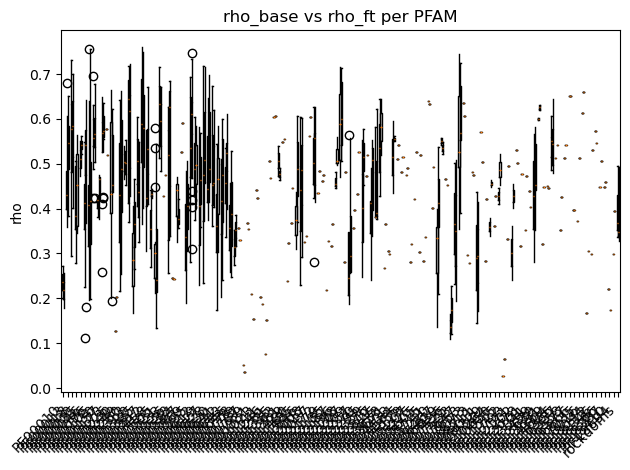

In [12]:
fig, ax = plt.subplots()

positions_base = np.arange(len(pfams)) * 2
positions_ft = positions_base + 0.6

ax.boxplot(base_data, positions=positions_base)
ax.boxplot(ft_data, positions=positions_ft)

ax.set_xticks(positions_base + 0.3)
ax.set_xticklabels(pfams, rotation=45, ha='right')

ax.set_ylabel("rho")
ax.set_title("rho_base vs rho_ft per PFAM")

plt.tight_layout()
plt.show()

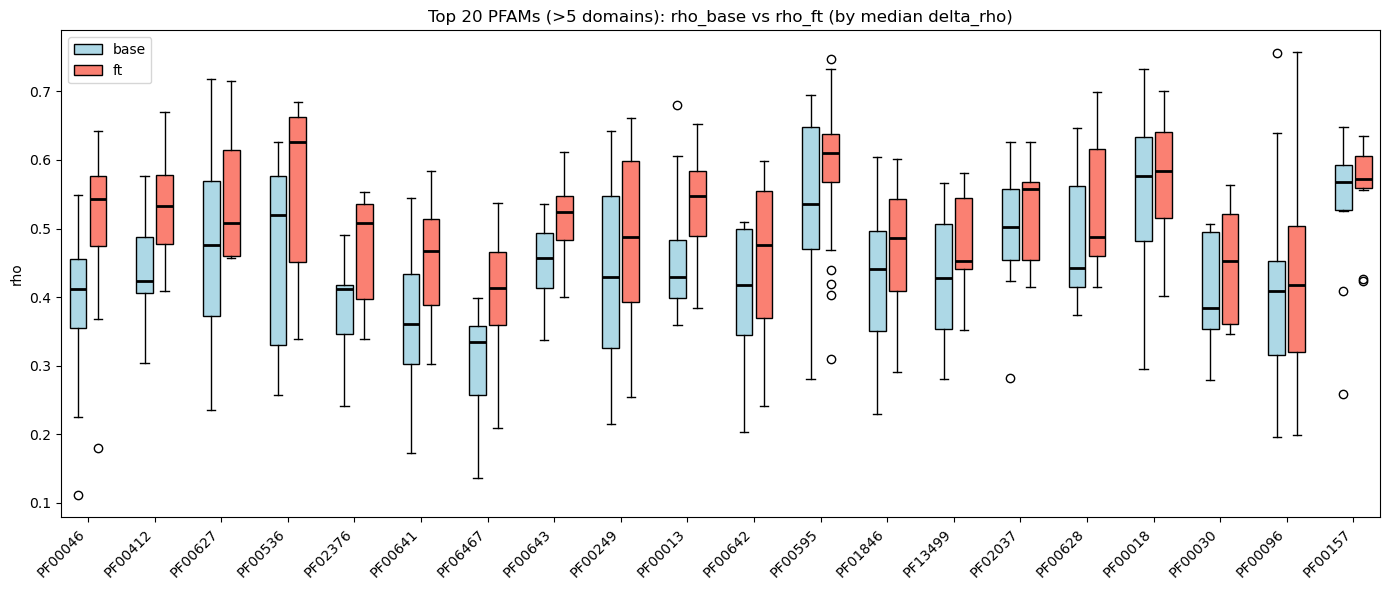

In [16]:
# --- Step 1: filter PFAMs with enough samples ---
pfam_counts = corr_df['pfam'].value_counts()
valid_pfams = pfam_counts[pfam_counts > 5].index
df_filt = corr_df[corr_df['pfam'].isin(valid_pfams)].copy()

# --- Step 2: select top 20 PFAMs by median delta_rho ---
top_pfams = (
    df_filt.groupby('pfam')['delta_rho']
    .median()
    .sort_values(ascending=False)
    .head(20)
    .index
)

df_top = df_filt[df_filt['pfam'].isin(top_pfams)].copy()

# --- Step 3: reshape for plotting ---
long_df = df_top.melt(
    id_vars=['pfam'],
    value_vars=['rho_base', 'rho_ft'],
    var_name='condition',
    value_name='rho'
)

# --- Step 4: build boxplot data ---
pfams = list(top_pfams)

base_data = []
ft_data = []

for pfam in pfams:
    base_data.append(
        long_df[(long_df['pfam'] == pfam) & (long_df['condition'] == 'rho_base')]['rho']
    )
    ft_data.append(
        long_df[(long_df['pfam'] == pfam) & (long_df['condition'] == 'rho_ft')]['rho']
    )

# --- Step 5: plot ---
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(pfams)) * 2
x_ft = x + 0.6

ax.boxplot(base_data, positions=x, patch_artist=True, 
           boxprops=dict(facecolor='lightblue'), label='base',
           medianprops=dict(color='black', linewidth=2))
ax.boxplot(ft_data, positions=x_ft, patch_artist=True, 
           boxprops=dict(facecolor='salmon'), label='ft',
           medianprops=dict(color='black', linewidth=2))

ax.set_xticks(x + 0.3)
ax.set_xticklabels(pfams, rotation=45, ha='right')

ax.set_ylabel("rho")
ax.set_title("Top 20 PFAMs (>5 domains): rho_base vs rho_ft (by median delta_rho)")

plt.legend()
plt.tight_layout()
plt.show()

In [17]:
corr_df.describe()

,n,rho_base,p_base,rho_ft,p_ft,delta_rho
count,522.000000,522.000000,5.220000e+02,522.000000,5.220000e+02,522.000000
mean,1027.134100,0.449464,1.321101e-03,0.489719,8.138765e-04,0.040255
std,340.285949,0.139498,2.549024e-02,0.129085,1.320337e-02,0.065459
min,306.000000,0.026799,2.920333e-242,0.035745,7.789702e-299,-0.125707
25%,793.750000,0.355668,6.635730e-86,0.418109,5.726450e-102,-0.007214
50%,1037.000000,0.448595,5.051548e-51,0.507501,4.078265e-64,0.031178
75%,1238.000000,0.546669,4.151965e-26,0.582534,3.350563e-37,0.080797
max,1804.000000,0.760929,5.754848e-01,0.756683,2.440298e-01,0.247267


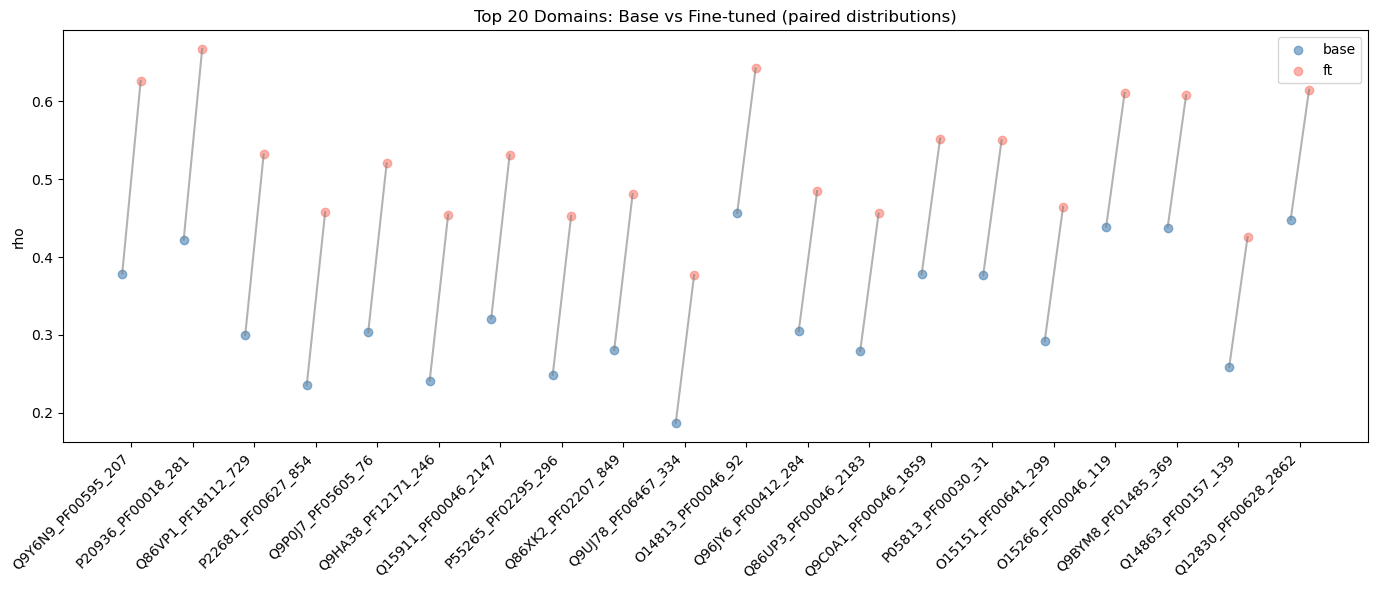

In [22]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(domains))

for i, d in enumerate(domains):
    base_vals = long_df[
        (long_df['domain_id'] == d) &
        (long_df['condition'] == 'rho_base')
    ]['rho'].values

    ft_vals = long_df[
        (long_df['domain_id'] == d) &
        (long_df['condition'] == 'rho_ft')
    ]['rho'].values

    # jitter so points don’t overlap
    x_base = np.full(len(base_vals), x[i] - 0.15)
    x_ft = np.full(len(ft_vals), x[i] + 0.15)

    # scatter points
    ax.scatter(x_base, base_vals, color='steelblue', alpha=0.6, label='base' if i == 0 else "")
    ax.scatter(x_ft, ft_vals, color='salmon', alpha=0.6, label='ft' if i == 0 else "")

    # connect means (or medians if you prefer)
    base_mean = np.mean(base_vals)
    ft_mean = np.mean(ft_vals)

    ax.plot([x[i] - 0.15, x[i] + 0.15],
            [base_mean, ft_mean],
            color='gray', alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels(domains, rotation=45, ha='right')

ax.set_ylabel("rho")
ax.set_title("Top 20 Domains: Base vs Fine-tuned (paired distributions)")

ax.legend()
plt.tight_layout()
plt.show()

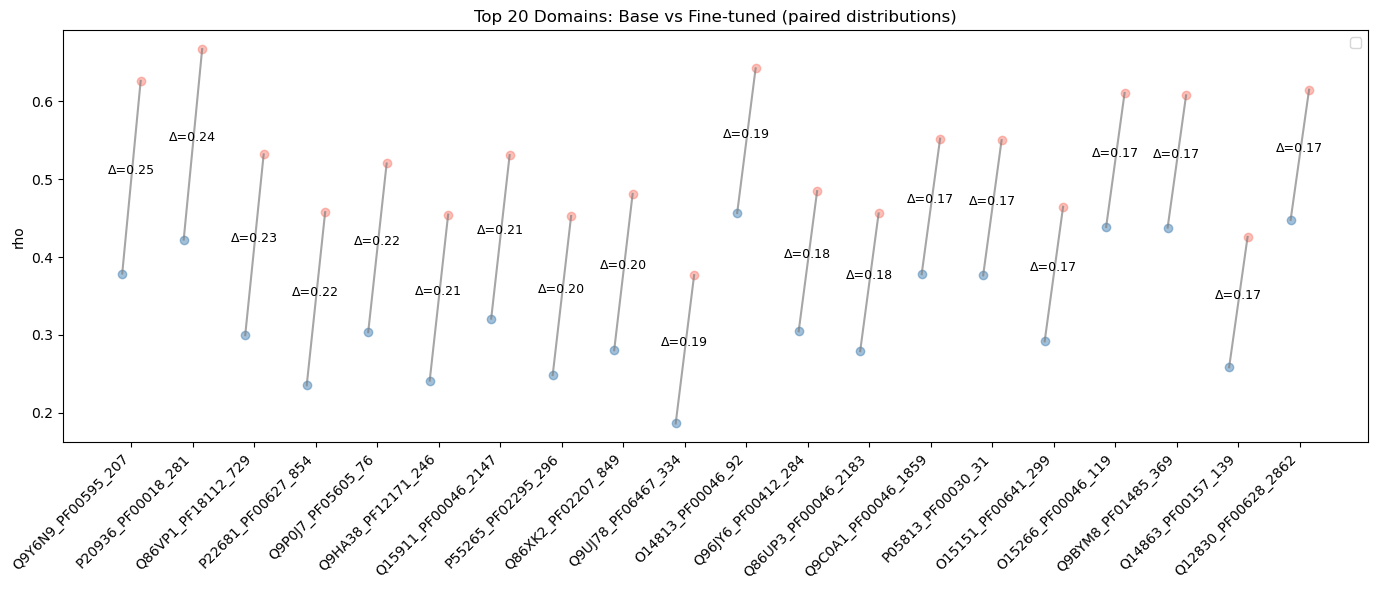

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(domains))

for i, d in enumerate(domains):
    base_vals = long_df[
        (long_df['domain_id'] == d) &
        (long_df['condition'] == 'rho_base')
    ]['rho'].values

    ft_vals = long_df[
        (long_df['domain_id'] == d) &
        (long_df['condition'] == 'rho_ft')
    ]['rho'].values

    # scatter (individual points)
    x_base = np.full(len(base_vals), x[i] - 0.15)
    x_ft = np.full(len(ft_vals), x[i] + 0.15)

    ax.scatter(x_base, base_vals, color='steelblue', alpha=0.5)
    ax.scatter(x_ft, ft_vals, color='salmon', alpha=0.5)

    # mean values for line
    base_mean = np.mean(base_vals)
    ft_mean = np.mean(ft_vals)

    # line
    ax.plot([x[i] - 0.15, x[i] + 0.15],
            [base_mean, ft_mean],
            color='gray', alpha=0.7)

    # --- Δrho label ---
    delta = ft_mean - base_mean

    mid_x = x[i]
    mid_y = (base_mean + ft_mean) / 2

    ax.text(
        mid_x,
        mid_y,
        f"Δ={delta:.2f}",
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )

ax.set_xticks(x)
ax.set_xticklabels(domains, rotation=45, ha='right')

ax.set_ylabel("rho")
ax.set_title("Top 20 Domains: Base vs Fine-tuned (paired deltas)")

ax.legend()
plt.tight_layout()
plt.show()

In [29]:
corr_df[['domain_id', 'n', 'uniprot_id', 'pfam', 'rho_base', 'rho_ft', 'delta_rho']].sort_values('delta_rho', ascending=False).head(20)

,domain_id,n,uniprot_id,pfam,rho_base,rho_ft,delta_rho
520,Q9Y6N9_PF00595_207,1255,Q9Y6N9,PF00595,0.378841,0.626107,0.247267
153,P20936_PF00018_281,1158,P20936,PF00018,0.422455,0.666935,0.244480
350,Q86VP1_PF18112_729,494,Q86VP1,PF18112,0.299746,0.531722,0.231976
155,P22681_PF00627_854,850,P22681,PF00627,0.235321,0.457595,0.222274
472,Q9P0J7_PF05605_76,1093,Q9P0J7,PF05605,0.303563,0.520061,0.216498
452,Q9HA38_PF12171_246,493,Q9HA38,PF12171,0.241383,0.454480,0.213098
304,Q15911_PF00046_2147,1055,Q15911,PF00046,0.320946,0.530762,0.209816
212,P55265_PF02295_296,1147,P55265,PF02295,0.248485,0.452707,0.204222
352,Q86XK2_PF02207_849,867,Q86XK2,PF02207,0.280419,0.481052,0.200633
488,Q9UJ78_PF06467_334,678,Q9UJ78,PF06467,0.186344,0.376808,0.190464
